## IMPORT LIBRARY

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = 'tulisan.jpg' 
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

print("Gambar berhasil dimuat!")

Gambar berhasil dimuat!


## MENAMPILKAN HISTOGRAM

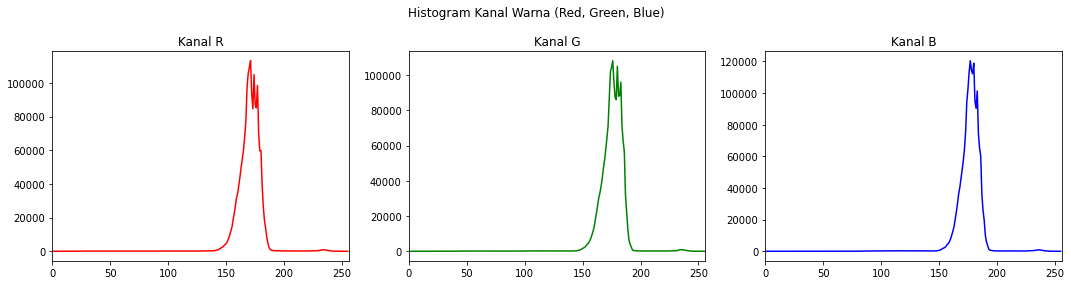

In [2]:
colors = ('r', 'g', 'b')
plt.figure(figsize=(15, 4))
plt.suptitle('Histogram Kanal Warna (Red, Green, Blue)')

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.subplot(1, 3, i+1)
    plt.plot(hist, color=color)
    plt.title(f'Kanal {color.upper()}')
    plt.xlim([0, 256])

plt.tight_layout()
plt.show()

In [3]:
# 1. Ambang batas Biru
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])
mask_blue = cv2.inRange(img_hsv, lower_blue, upper_blue)

# 2. Ambang batas Hijau
lower_green = np.array([40, 50, 50])
upper_green = np.array([85, 255, 255])
mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

# 3. Ambang batas Merah 
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
mask_red1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

lower_red2 = np.array([160, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask_red2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

mask_red = cv2.bitwise_or(mask_red1, mask_red2)

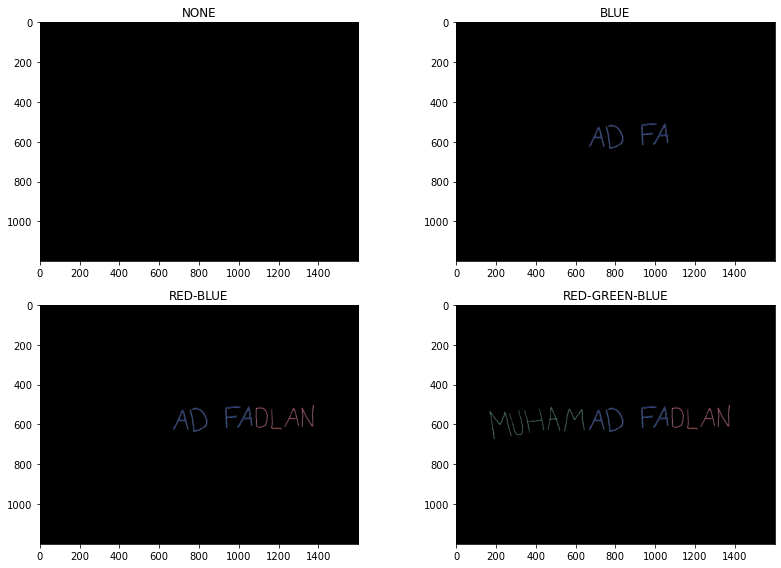

In [4]:
img_none = np.zeros_like(img_rgb)
img_blue = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_blue)
mask_red_blue = cv2.bitwise_or(mask_red, mask_blue)
img_red_blue = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_red_blue)

mask_all = cv2.bitwise_or(mask_red_blue, mask_green)
img_all = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_all)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img_none)
axs[0, 0].set_title('NONE')

axs[0, 1].imshow(img_blue)
axs[0, 1].set_title('BLUE')

axs[1, 0].imshow(img_red_blue)
axs[1, 0].set_title('RED-BLUE')

axs[1, 1].imshow(img_all)
axs[1, 1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

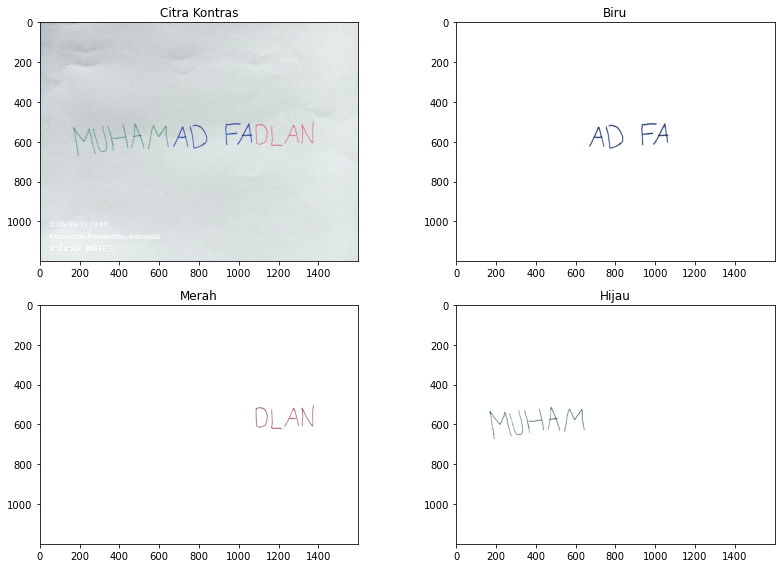

In [6]:
img_kontras = cv2.convertScaleAbs(img_rgb, alpha=1.2, beta=10)

img_biru_only = np.full_like(img_rgb, 255)
img_merah_only = np.full_like(img_rgb, 255)
img_hijau_only = np.full_like(img_rgb, 255)

img_biru_only[mask_blue > 0] = img_rgb[mask_blue > 0]
img_merah_only[mask_red > 0] = img_rgb[mask_red > 0]
img_hijau_only[mask_green > 0] = img_rgb[mask_green > 0]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img_kontras)
axs[0, 0].set_title('Citra Kontras')

axs[0, 1].imshow(img_biru_only)
axs[0, 1].set_title('Biru')

axs[1, 0].imshow(img_merah_only)
axs[1, 0].set_title('Merah')

axs[1, 1].imshow(img_hijau_only)
axs[1, 1].set_title('Hijau')

plt.tight_layout()
plt.show()